In [89]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from ates.models.simple import slope_deg as compute_slope_deg
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

import autoates_v2

DATA = (Path(autoates_v2.__file__).parent / "test-data" / "Bow Summit").resolve()
OUTPUTS = DATA / "outputs"

# Bow Summit — Feature Analysis

Bow Summit is the only area with all v2 intermediate rasters pre-computed.
Each raster is flattened to one row per valid pixel, then joined into a single
DataFrame for analysis. Valid pixels are those where the final ATES class is not nodata.




**Question**: Could a convex be detected in MRDEM or HRDEM?

### Glossary & Theory
- **FP**: [FlowPy](https://github.com/avaframe/FlowPy) is a tool to compute gravitational mass flows (GMF) run out and intensity
- **SAT**: Slope Angle Threshold (0-3/4)
  - 3 is ATES v1
  - 4 is for ATES v2
- **AAT**: Alpha Angle Threshold 
- **PRA**: Potential Release Areas. Typically slopes between 30-50°
  - [Veitinger Criteria](https://nhess.copernicus.org/articles/16/2211/2016/nhess-16-2211-2016.pdf):
    - 30-60°
    - Wind-affected
    - Sparsely forested
- **Forest BAV**: Basal Area per Volume ($m^2/ha$). 
  - Cross-sectional of tree trunks at breast height -> how likely the trees are to stop the avie
- **Breast Height**: 1.3m
- **CCI**: Cell Count Criteria (criterion)

#### Alpha Angle
https://github.com/avaframe/FlowPy
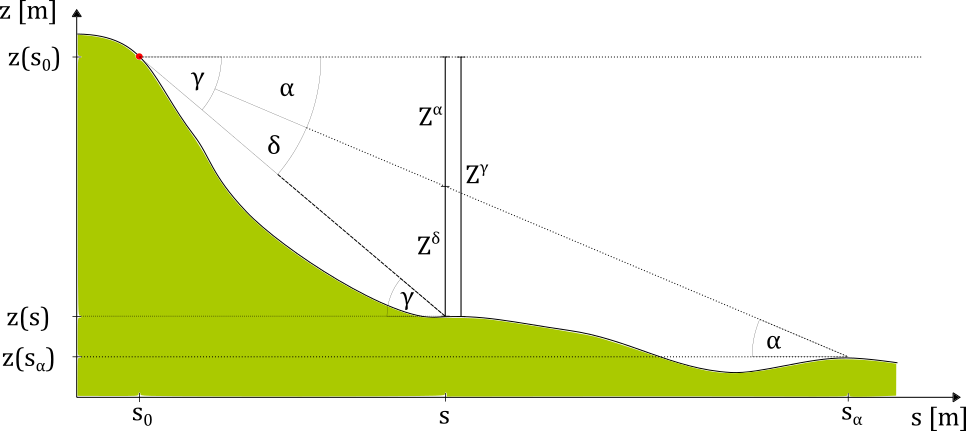
- Big runout = small alpha angle
- FlowPy writes one alpha value per pixel using a [D8 routing algorithm](https://hydrology.usu.edu/taudem/taudem5/help/d8flowdirections.html)
- **This is the feature that separates challenging from simple**: A lot more slopes would be simple if the overhead terrain is not included

#### 

### Initial Thoughts

- The continuous data is being obscured by using classes
- This data could be put to better use in numeric form
- [Pistocchi et al, 2012](https://sci-hub.red/10.1007/s11069-012-0410-3) used a continuous method

### Combine Rasters into DataFrame

Combine individual rasters into DataFrame to facilitate feature extraction

1. `elevation`: vertical distance from sea-level (m)
2. `slope_deg`: angle of the slope (°)
3. `slope_class`: slope classification (0-4)
4. `fp_alpha`: angle between the PRA and to the end of the runout. 
5. `fp_class`: class assigned to alpha angle. (0-3)
6. `overhead_count`: number of upslope cells above a point (no. of pixels)
7. `overhead_class`:
8. `forest_bav`: measure of forested an area is ($m^2/ha$)
9. `forest_class`: forest classification (0-3)
10. `pra_binary`: potential release area: yes or no. (0 | 1) -> very influential feature
11. `ates_v2`: predicted ATES from file

In [32]:
def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr


# Compute continuous slope from the DEM — outputs/slope.tif is the classified version (0–4)
with rasterio.open(DATA / "dem.tif") as src:
    dem_arr = src.read(1).astype(np.float32)
    if src.nodata is not None:
        dem_arr[dem_arr == src.nodata] = np.nan
    res_x, res_y = abs(src.transform.a), abs(src.transform.e)

rasters = {
    "elevation": dem_arr,
    "slope_deg": compute_slope_deg(dem_arr, res_x=res_x, res_y=res_y),
    "slope_class": read_band(OUTPUTS / "slope.tif"),
    "fp_alpha": read_band(DATA / "FP_int16.tif"),
    "fp_class": read_band(OUTPUTS / "flowpy.tif"),
    "overhead_count": read_band(DATA / "Overhead.tif"),
    "overhead_class": read_band(OUTPUTS / "cellcount_reclass.tif"),
    "forest_bav": read_band(DATA / "forest.tif"),
    "forest_class": read_band(OUTPUTS / "forest_reclass.tif"),
    "pra_binary": read_band(DATA / "pra_binary.tif"),
    "ates_v2": read_band(OUTPUTS / "ates_gen.tif"),
}

ates = rasters["ates_v2"]
valid = np.isfinite(ates) & (ates != -9999) & (ates > 0)

df = pd.DataFrame({k: v[valid].astype(np.float32) for k, v in rasters.items()})
df["ates_v2"] = df["ates_v2"].astype(int)

print(df.shape)
df.describe()

(31182, 11)


,elevation,slope_deg,slope_class,fp_alpha,fp_class,overhead_count,overhead_class,forest_bav,forest_class,pra_binary,ates_v2
count,31090.000000,31090.000000,30202.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000
mean,2174.134033,19.652370,1.290775,15.333846,1.677955,15.914085,1.623308,11.813610,19.038548,0.228690,1.852511
std,235.464813,15.710860,1.421551,18.214392,0.836379,20.427622,0.789702,16.418331,13.276068,0.419996,1.040822
min,1831.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,0.000000,1.000000
25%,2003.000000,6.647439,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,0.000000,1.000000
50%,2082.000000,16.778273,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,10.000000,0.000000,1.000000
75%,2319.000000,30.073280,3.000000,32.000000,2.000000,36.000000,2.000000,25.000000,40.000000,0.000000,3.000000
max,2954.000000,87.536789,4.000000,70.000000,3.000000,77.000000,3.000000,50.000000,40.000000,1.000000,4.000000


### Exploratory Analysis

Columns with many zeros:

1. `slope_class`: 47.7% (This is classification so probably fine)
2. `fp_alpha`: 56.2%
3. `fp_class`: 56.2% (skewed by fp_alpha)
4. `overhead_count`: 56.7%
5.  `overhead_class`: 57.1%
6.  `forest_bav`: 45.7%
7.  `forest_class`: 65.5%
8.  `pra_binary`: 77.13%


In [88]:
df.ates_v2.value_counts()

ates_v2
1    17334
3     8347
2     3307
4     2194
Name: count, dtype: int64

In [78]:
[{col: float(df[col].value_counts().max() / df.shape[0]) * 100} for col in df.columns]

[{'elevation': 2.2961965236354307},
 {'slope_deg': 3.7265088833301263},
 {'slope_class': 47.719838368289395},
 {'fp_alpha': 56.26322878583798},
 {'fp_class': 56.26322878583798},
 {'overhead_count': 56.75389647873773},
 {'overhead_class': 57.109871079468924},
 {'forest_bav': 45.73471874799564},
 {'forest_class': 65.4672567506895},
 {'pra_binary': 77.1310371368097},
 {'ates_v2': 55.58976332499519}]

<Axes: ylabel='Frequency'>

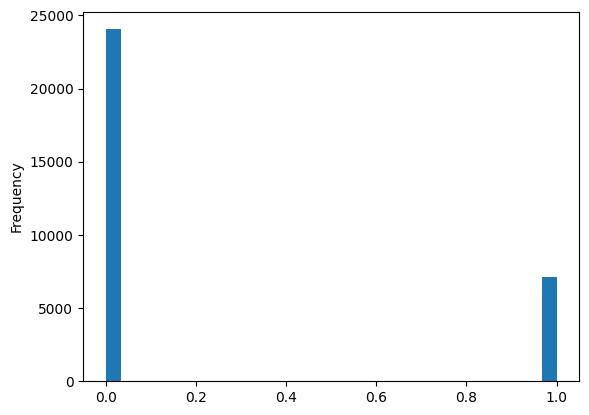

In [87]:
df.pra_binary.plot.hist(bins=30)

In [93]:
sns.violinplot

<function seaborn.categorical.violinplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, inner='box', split=False, width=0.8, dodge='auto', gap=0, linewidth=None, linecolor='auto', cut=2, gridsize=100, bw_method='scott', bw_adjust=1, density_norm='area', common_norm=False, hue_norm=None, formatter=None, log_scale=None, native_scale=False, legend='auto', scale=<deprecated>, scale_hue=<deprecated>, bw=<deprecated>, inner_kws=None, ax=None, **kwargs)>